# 🎮 Video Game Sales Data Analysis (1980–2024)

## Introduction

*This project analyzes video game sales data from 1980 to 2024. 
*The goal is to identify top-performing games, genres, and platforms, 
*as well as analyze sales trends over time.

In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [5]:
df = pd.read_csv("Video Games Sales (1980-2024) - Raw.csv")
df.head()

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,17-09-2013,NaN
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,18-11-2014,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,28-10-2002,NaN
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,NaN,15.86,9.06,0.06,5.33,1.42,17-09-2013,NaN
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,06-11-2015,14-01-2018


## Data Cleaning

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 64016 entries, 0 to 64015
Data columns (total 14 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   img           64016 non-null  object 
 1   title         64016 non-null  object 
 2   console       64016 non-null  object 
 3   genre         64016 non-null  object 
 4   publisher     64016 non-null  object 
 5   developer     63999 non-null  object 
 6   critic_score  6678 non-null   float64
 7   total_sales   18922 non-null  float64
 8   na_sales      12637 non-null  float64
 9   jp_sales      6726 non-null   float64
 10  pal_sales     12824 non-null  float64
 11  other_sales   15128 non-null  float64
 12  release_date  56965 non-null  object 
 13  last_update   17879 non-null  object 
dtypes: float64(6), object(8)
memory usage: 6.8+ MB


In [13]:
df.describe()

,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales
count,6678.000000,18922.000000,12637.000000,6726.000000,12824.000000,15128.000000
mean,7.220440,0.349113,0.264740,0.102281,0.149472,0.043041
std,1.457066,0.807462,0.494787,0.168811,0.392653,0.126643
min,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,6.400000,0.030000,0.050000,0.020000,0.010000,0.000000
50%,7.500000,0.120000,0.120000,0.040000,0.040000,0.010000
75%,8.300000,0.340000,0.280000,0.120000,0.140000,0.030000
max,10.000000,20.320000,9.760000,2.130000,9.850000,3.120000


In [15]:
df.isnull().sum()


img                 0
title               0
console             0
genre               0
publisher           0
developer          17
critic_score    57338
total_sales     45094
na_sales        51379
jp_sales        57290
pal_sales       51192
other_sales     48888
release_date     7051
last_update     46137
dtype: int64

In [21]:
df = df.drop_duplicates()                         #- Removed duplicate records - Handled missing values

df['release_date'] = pd.to_datetime(df['release_date'], errors='coerce')

df.fillna(0, inplace=True)

In [23]:
df.isnull().sum()  


img             0
title           0
console         0
genre           0
publisher       0
developer       0
critic_score    0
total_sales     0
na_sales        0
jp_sales        0
pal_sales       0
other_sales     0
release_date    0
last_update     0
dtype: int64

## Data Analysis

In [25]:
df.sort_values(by='total_sales', ascending=False).head(10)  # TOP SELLING GAME

,img,title,console,genre,publisher,developer,critic_score,total_sales,na_sales,jp_sales,pal_sales,other_sales,release_date,last_update
0,/games/boxart/full_6510540AmericaFrontccc.jpg,Grand Theft Auto V,PS3,Action,Rockstar Games,Rockstar North,9.4,20.32,6.37,0.99,9.85,3.12,2013-09-17,0
1,/games/boxart/full_5563178AmericaFrontccc.jpg,Grand Theft Auto V,PS4,Action,Rockstar Games,Rockstar North,9.7,19.39,6.06,0.60,9.71,3.02,2014-11-18,03-01-2018
2,/games/boxart/827563ccc.jpg,Grand Theft Auto: Vice City,PS2,Action,Rockstar Games,Rockstar North,9.6,16.15,8.41,0.47,5.49,1.78,2002-10-28,0
3,/games/boxart/full_9218923AmericaFrontccc.jpg,Grand Theft Auto V,X360,Action,Rockstar Games,Rockstar North,0.0,15.86,9.06,0.06,5.33,1.42,2013-09-17,0
4,/games/boxart/full_4990510AmericaFrontccc.jpg,Call of Duty: Black Ops 3,PS4,Shooter,Activision,Treyarch,8.1,15.09,6.18,0.41,6.05,2.44,2015-11-06,14-01-2018
5,/games/boxart/full_call-of-duty-modern-warfare...,Call of Duty: Modern Warfare 3,X360,Shooter,Activision,Infinity Ward,8.7,14.82,9.07,0.13,4.29,1.33,2011-11-08,0
6,/games/boxart/full_call-of-duty-black-ops_5Ame...,Call of Duty: Black Ops,X360,Shooter,Activision,Treyarch,8.8,14.74,9.76,0.11,3.73,1.14,2010-11-09,0
7,/games/boxart/full_4653215AmericaFrontccc.jpg,Red Dead Redemption 2,PS4,Action-Adventure,Rockstar Games,Rockstar Games,9.8,13.94,5.26,0.21,6.21,2.26,2018-10-26,02-11-2018
8,/games/boxart/full_1977964AmericaFrontccc.jpg,Call of Duty: Black Ops II,X360,Shooter,Activision,Treyarch,8.4,13.86,8.27,0.07,4.32,1.20,2012-11-13,07-04-2018
9,/games/boxart/full_4649679AmericaFrontccc.png,Call of Duty: Black Ops II,PS3,Shooter,Activision,Treyarch,8.0,13.80,4.99,0.65,5.88,2.28,2012-11-13,07-04-2018


In [27]:
df.groupby('genre')['total_sales'].sum().sort_values(ascending=False)  # selling by genre

genre
Sports              1187.51
Action              1125.89
Shooter              995.50
Misc                 557.79
Racing               525.75
Role-Playing         426.80
Platform             349.15
Fighting             341.13
Adventure            325.39
Simulation           300.65
Action-Adventure     148.52
Puzzle               127.28
Strategy             118.31
Music                 51.75
MMO                    9.31
Party                  6.21
Visual Novel           5.78
Sandbox                1.89
Education              0.97
Board Game             0.33
Name: total_sales, dtype: float64

In [28]:
df.groupby('console')['total_sales'].sum().sort_values(ascending=False)

console
PS2     1027.76
X360     859.79
PS3      839.70
PS       546.25
PS4      539.92
         ...   
TG16       0.00
XS         0.00
ZXS        0.00
iOS        0.00
iQue       0.00
Name: total_sales, Length: 81, dtype: float64

In [30]:
df['year'] = df['release_date'].dt.year

df.groupby('year')['total_sales'].sum()

year
1970      6.59
1971      0.00
1973      0.00
1975      0.00
1977      2.50
1978      2.36
1979      0.31
1980      2.26
1981      7.73
1982     28.99
1983     22.68
1984      4.85
1985      2.19
1986     10.35
1987      5.59
1988      8.73
1989      9.12
1990      9.07
1991      6.05
1992      9.38
1993     20.16
1994     36.85
1995     52.98
1996    101.36
1997    105.89
1998    132.23
1999    169.61
2000    171.12
2001    226.75
2002    314.50
2003    300.89
2004    284.68
2005    313.48
2006    244.42
2007    436.39
2008    538.11
2009    495.36
2010    454.02
2011    440.32
2012    285.47
2013    266.00
2014    292.11
2015    230.45
2016    208.02
2017    191.96
2018    148.03
2019      2.55
2020      3.45
2021      0.00
2022      0.00
2023      0.00
2024      0.00
Name: total_sales, dtype: float64

In [32]:
df[['na_sales','jp_sales','pal_sales','other_sales']].sum()

na_sales       3345.52
jp_sales        687.94
pal_sales      1916.83
other_sales     651.12
dtype: float64

## Visualization

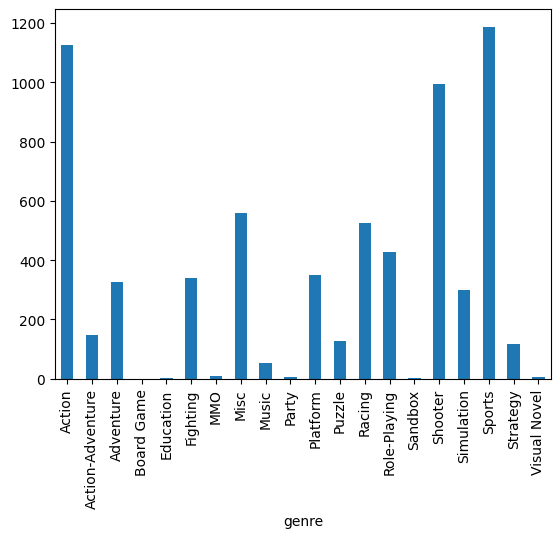

In [8]:


df.groupby('genre')['total_sales'].sum().plot(kind='bar')
plt.show()

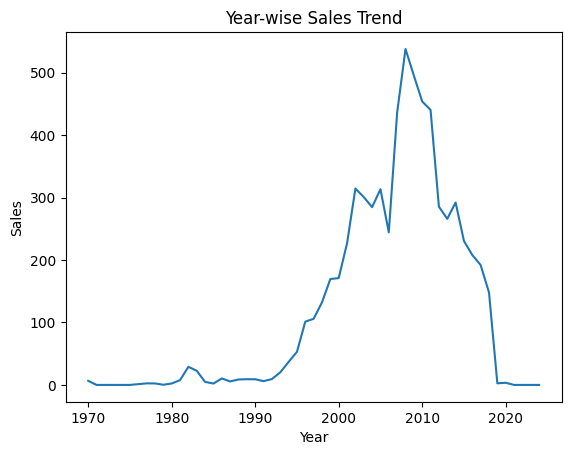

In [39]:
year_sales = df.groupby('year')['total_sales'].sum()

year_sales.plot()
plt.title("Year-wise Sales Trend")
plt.xlabel("Year")
plt.ylabel("Sales")
plt.show()

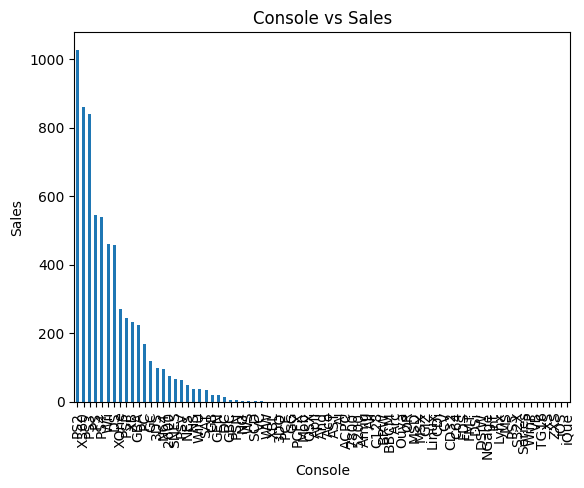

In [42]:
console_sales = df.groupby('console')['total_sales'].sum().sort_values(ascending=False)

console_sales.plot(kind='bar')
plt.title("Console vs Sales")
plt.xlabel("Console")
plt.ylabel("Sales")
plt.show()

In [35]:
df.groupby('publisher')['total_sales'].sum().sort_values(ascending=False).head(10)

publisher
Activision                     722.77
Electronic Arts                644.13
EA Sports                      485.66
Ubisoft                        462.57
THQ                            320.89
Sony Computer Entertainment    311.08
Rockstar Games                 239.67
Konami                         210.70
Sega                           206.38
Nintendo                       140.80
Name: total_sales, dtype: float64

## Key Insights

In [ ]:
1. Top Selling Game

 “The highest selling video game is Grand Theft Auto V with total sales of 20.32 million units.”

2. Most Popular Genre

“The most popular genre is Sports, contributing the highest share in total sales.”

3. Top Console / Platform
“PS2 is the top performing console with maximum total sales.”

 4. Sales Trend

 “Sales increased rapidly between 2000 and 2008, and then started declining after 2009.”

5. Region-wise Insight

“North America contributes the highest sales, followed by Europe and Japan.”


- Action genre has highest sales
- Sales peaked between 2000–2008
- North America has highest contribution